# **Norwegian News Articles**
Project for TDT4310

By: Malin Haugland Høli

### *Imports*

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

### *Load processed data and combine into one dataset*

In [ ]:
# Load VG (Verdens Gang) data
df_vg_nob = pd.read_parquet("../processed/vg-2019-nob.parquet")
df_vg_nno = pd.read_parquet("../processed/vg-2019-nno.parquet")

# Load Adressa data
df_aa_nob = pd.read_parquet("../processed/aa-2019-nob.parquet")
df_aa_nno = pd.read_parquet("../processed/aa-2019-nno.parquet")

# Load Aftenposten data
df_ap_nob = pd.read_parquet("../processed/ap-2019-nob.parquet")
df_ap_nno = pd.read_parquet("../processed/ap-2019-nno.parquet")

# Load Bergens Tidende data
df_bt_nob = pd.read_parquet("../processed/bt-2019-nob.parquet")
df_bt_nno = pd.read_parquet("../processed/bt-2019-nno.parquet")

# Load Dagsavisen data
df_da_nob = pd.read_parquet("../processed/da-2019-nob.parquet")
df_da_nno = pd.read_parquet("../processed/da-2019-nno.parquet")

# Load Dagens Næringsliv data
df_dn_nob = pd.read_parquet("../processed/dn-2019-nob.parquet")
df_dn_nno = pd.read_parquet("../processed/dn-2019-nno.parquet")

# Load Dagbladet data
df_db_nob = pd.read_parquet("../processed/db-2019-nob.parquet")
df_db_nno = pd.read_parquet("../processed/db-2019-nno.parquet")

# Load Fædrelandsvennen data
df_fv_nob = pd.read_parquet("../processed/fv-2019-nob.parquet")
df_fv_nno = pd.read_parquet("../processed/fv-2019-nno.parquet")

# Load Nordlys data
df_nl_nob = pd.read_parquet("../processed/nl-2019-nob.parquet")
df_nl_nno = pd.read_parquet("../processed/nl-2019-nno.parquet")

# Load Stavanger Aftenblad data
df_sa_nob = pd.read_parquet("../processed/sa-2019-nob.parquet")
df_sa_nno = pd.read_parquet("../processed/sa-2019-nno.parquet")

combined_df = pd.concat([df_vg_nob, df_vg_nno, df_aa_nob, df_aa_nno, df_ap_nob, df_ap_nno, df_bt_nob, df_bt_nno, 
                     df_da_nob, df_da_nno, df_dn_nob, df_dn_nno, df_db_nob, df_db_nno, df_fv_nob, df_fv_nno, 
                     df_nl_nob, df_nl_nno, df_sa_nob, df_sa_nno], ignore_index=True)

In [23]:
combined_df.head(3)

,file,url,source,date,author,gender,class1,class2,language,author_empty,title,ingress,text,word_count,sentence_count
0,VG-20190101---oljen-er-en-stor-t.xml,http://www.vg.no/nyheter/innenriks/i/vmKbjw/ol...,VG,2019-01-01 06:12,,U,"nyheter,innenriks","Nyheter, Innenriks",nob,True,– Oljen er en stor trussel,RØST (VG) Tor Henrik Andreassen jobber som fis...,,0,0
1,VG-20190101-16-personer-fikk-oye.xml,http://www.vg.no/nyheter/innenriks/i/jPyoyb/16...,VG,2019-01-01 09:12,Halvor Bjørntvedt,M,"nyheter,innenriks",,nob,False,16 personer fikk øyeskader av fyrverkeri,Fem fikk alvorlige skader etter gårsdagens nyt...,"Tallene, som viser øyeskader på landsbasis, vi...",209,13
2,VG-20190101-47-plass-for-sundby-.xml,http://www.vg.no/sport/langrenn/i/3j8ra0/47-pl...,VG,2019-01-01 10:19,"Nils Mangelrød, Jostein Overvik",M,"sport,langrenn",,nob,False,47. plass for Sundby - nekter å prate etter ne...,VAL MÜSTAIR (VG) Martin Johnsrud nektet å prat...,Den tidligere Tour de Ski-vinneren var svært l...,533,42


In [24]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179292 entries, 0 to 179291
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   file            179292 non-null  object
 1   url             179292 non-null  object
 2   source          179292 non-null  object
 3   date            179292 non-null  object
 4   author          179292 non-null  object
 5   gender          179292 non-null  object
 6   class1          179292 non-null  object
 7   class2          179292 non-null  object
 8   language        179292 non-null  object
 9   author_empty    179292 non-null  bool  
 10  title           179292 non-null  object
 11  ingress         173860 non-null  object
 12  text            179292 non-null  object
 13  word_count      179292 non-null  int64 
 14  sentence_count  179292 non-null  int64 
dtypes: bool(1), int64(2), object(12)
memory usage: 19.3+ MB


## ***Preprocessing***

### *Check for articles with empty text field*

The analysis is heavily based on the article text, so articles where the text has not been captured are not relevant for the analysis

In [25]:
# Print number of articles with empty text in the combined dataset, grouped by source and language
print("Checking for empty text field in combined dataset:")
print("-" * 50)

summary = (
    combined_df.assign(empty_text=combined_df["text"].str.strip() == "")
    .groupby(["source", "language"], dropna=False)
    .agg(total=("text", "size"), empty_text=("empty_text", "sum"))
    .reset_index()
    .sort_values(["source", "language"])
)

for _, row in summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    empty = int(row["empty_text"])
    total = int(row["total"])
    pct = (empty / total * 100) if total else 0
    print(f"{src} ({lang}): Articles with empty text: {empty} / {total} ({pct:.1f}%)")


Checking for empty text field in combined dataset:
--------------------------------------------------
AA (nno): Articles with empty text: 0 / 25 (0.0%)
AA (nob): Articles with empty text: 7 / 11618 (0.1%)
AP (nno): Articles with empty text: 2 / 97 (2.1%)
AP (nob): Articles with empty text: 141 / 27341 (0.5%)
BT (nbo): Articles with empty text: 7182 / 13837 (51.9%)
DA (nno): Articles with empty text: 4 / 45 (8.9%)
DA (nob): Articles with empty text: 1376 / 13065 (10.5%)
DB (nno): Articles with empty text: 1 / 65 (1.5%)
DB (nob): Articles with empty text: 1578 / 23756 (6.6%)
DN (nno): Articles with empty text: 8 / 24 (33.3%)
DN (nob): Articles with empty text: 3888 / 13218 (29.4%)
FV (nno): Articles with empty text: 39 / 43 (90.7%)
FV (nob): Articles with empty text: 8639 / 11418 (75.7%)
NL (nno): Articles with empty text: 7 / 70 (10.0%)
NL (nob): Articles with empty text: 5564 / 10773 (51.6%)
SA (nno): Articles with empty text: 444 / 821 (54.1%)
SA (nob): Articles with empty text: 15958

### *Remove articles with empty text field*

In [26]:
# Remove articles with empty text in the combined df and print each source and language with the new counts
combined_df = combined_df[combined_df["text"].str.strip() != ""].reset_index(drop=True)

summary = (
    combined_df.groupby(["source", "language"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["source", "language"])
)

print("\nTotal articles after removing empty text:")
print("-" * 50)
for _, row in summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    count = int(row["count"])
    print(f"{src} ({lang}): Number of articles: {count}")


Total articles after removing empty text:
--------------------------------------------------
AA (nno): Number of articles: 25
AA (nob): Number of articles: 11611
AP (nno): Number of articles: 95
AP (nob): Number of articles: 27200
BT (nbo): Number of articles: 6655
DA (nno): Number of articles: 41
DA (nob): Number of articles: 11689
DB (nno): Number of articles: 64
DB (nob): Number of articles: 22178
DN (nno): Number of articles: 16
DN (nob): Number of articles: 9330
FV (nno): Number of articles: 4
FV (nob): Number of articles: 2779
NL (nno): Number of articles: 63
NL (nob): Number of articles: 5209
SA (nno): Number of articles: 377
SA (nob): Number of articles: 14771
VG (nno): Number of articles: 32
VG (nob): Number of articles: 20302


### *Check for empty author field*

In [27]:
# check for "" in author column and count how many for each source and language and print the results
print("\nChecking for empty author field in combined dataset:")
print("-" * 50)
author_summary = (
    combined_df.assign(empty_author=combined_df["author"].str.strip() == "")
    .groupby(["source", "language"], dropna=False)
    .agg(total=("author", "size"), empty_author=("empty_author", "sum"))
    .reset_index()
    .sort_values(["source", "language"])
)
for _, row in author_summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    empty = int(row["empty_author"])
    total = int(row["total"])
    pct = (empty / total * 100) if total else 0
    print(f"{src} ({lang}): Articles with empty author: {empty} / {total} ({pct:.1f}%)")


Checking for empty author field in combined dataset:
--------------------------------------------------
AA (nno): Articles with empty author: 25 / 25 (100.0%)
AA (nob): Articles with empty author: 4572 / 11611 (39.4%)
AP (nno): Articles with empty author: 1 / 95 (1.1%)
AP (nob): Articles with empty author: 801 / 27200 (2.9%)
BT (nbo): Articles with empty author: 1564 / 6655 (23.5%)
DA (nno): Articles with empty author: 9 / 41 (22.0%)
DA (nob): Articles with empty author: 1520 / 11689 (13.0%)
DB (nno): Articles with empty author: 1 / 64 (1.6%)
DB (nob): Articles with empty author: 257 / 22178 (1.2%)
DN (nno): Articles with empty author: 0 / 16 (0.0%)
DN (nob): Articles with empty author: 69 / 9330 (0.7%)
FV (nno): Articles with empty author: 0 / 4 (0.0%)
FV (nob): Articles with empty author: 323 / 2779 (11.6%)
NL (nno): Articles with empty author: 0 / 63 (0.0%)
NL (nob): Articles with empty author: 13 / 5209 (0.2%)
SA (nno): Articles with empty author: 30 / 377 (8.0%)
SA (nob): Article

### *Remove articles with empty author field*

In [ ]:
combined_df = combined_df[combined_df["author"].str.strip() != ""].reset_index(drop=True)
combined_df = combined_df.drop(columns=["author_empty"], errors="ignore")

author_summary = (
    combined_df.groupby(["source", "language"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["source", "language"])
)
print("\nTotal articles after removing empty author:")
print("-" * 50)
for _, row in author_summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    count = int(row["count"])
    print(f"{src} ({lang}): Number of articles: {count}")


Total articles after removing empty author:
--------------------------------------------------
AA (nob): Number of articles: 7039
AP (nno): Number of articles: 94
AP (nob): Number of articles: 26399
BT (nbo): Number of articles: 5091
DA (nno): Number of articles: 32
DA (nob): Number of articles: 10169
DB (nno): Number of articles: 63
DB (nob): Number of articles: 21921
DN (nno): Number of articles: 16
DN (nob): Number of articles: 9261
FV (nno): Number of articles: 4
FV (nob): Number of articles: 2456
NL (nno): Number of articles: 63
NL (nob): Number of articles: 5196
SA (nno): Number of articles: 347
SA (nob): Number of articles: 13918
VG (nob): Number of articles: 8823


In [29]:
combined_df.head(5)

,file,url,source,date,author,gender,class1,class2,language,title,ingress,text,word_count,sentence_count
0,VG-20190101-16-personer-fikk-oye.xml,http://www.vg.no/nyheter/innenriks/i/jPyoyb/16...,VG,2019-01-01 09:12,Halvor Bjørntvedt,M,"nyheter,innenriks",,nob,16 personer fikk øyeskader av fyrverkeri,Fem fikk alvorlige skader etter gårsdagens nyt...,"Tallene, som viser øyeskader på landsbasis, vi...",209,13
1,VG-20190101-47-plass-for-sundby-.xml,http://www.vg.no/sport/langrenn/i/3j8ra0/47-pl...,VG,2019-01-01 10:19,"Nils Mangelrød, Jostein Overvik",M,"sport,langrenn",,nob,47. plass for Sundby - nekter å prate etter ne...,VAL MÜSTAIR (VG) Martin Johnsrud nektet å prat...,Den tidligere Tour de Ski-vinneren var svært l...,533,42
2,VG-20190101-94-drap-pa-journalis.xml,http://www.vg.no/nyheter/utenriks/i/J19kWP/94-...,VG,2019-01-01 21:37,Mikal Hem,M,"nyheter,utenriks","Drap, Ytringsfrihet, Journalistikk, Korrupsjon...",nob,94 drap på journalister i 2018: Skal ha blitt ...,Antall drepte journalister i Vesten har skutt ...,25. februar ble Jan Kuciak og hans forlovede M...,539,44
3,VG-20190101-alpin-fiasko-i-kolle.xml,http://www.vg.no/sport/alpint/i/VR7Kb6/alpin-f...,VG,2019-01-01 16:09,Herman Tinius Folvik,M,"sport,alpint",,nob,Alpin-fiasko i Kollen: Alle de norske slått ut...,"De store håpene, Henrik Kristoffersen og Ragnh...",Mowinckel kunne trolig ikke fått en tøffere mo...,190,21
4,VG-20190101-arsenal-slo-tilbake-.xml,http://www.vg.no/sport/fotball/i/EoPO3l/arsena...,VG,2019-01-01 16:54,Yngve Gjerde,M,"sport,fotball",,nob,Arsenal slo tilbake etter Liverpool-fadesen,(Arsenal – Fulham 4 – 1) Arsenal avsluttet fot...,"Scoringer fra Granit Xhaka, Alexandre Lacazett...",272,15


### *Print unique author for each source and written language*

In [ ]:
print("\nNumber of unique authors in combined dataset:")
author_counts = (
    combined_df.groupby(["source", "language"], dropna=False)["author"]
    .nunique()
    .reset_index(name="unique_authors")
    .sort_values(["source", "language"])
)
for _, row in author_counts.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    unique = int(row["unique_authors"])
    print(f"{src} ({lang}): Unique authors: {unique}")


Number of unique authors in combined dataset:
AA (nob): Unique authors: 917
AP (nno): Unique authors: 60
AP (nob): Unique authors: 2272
BT (nbo): Unique authors: 1430
DA (nno): Unique authors: 9
DA (nob): Unique authors: 594
DB (nno): Unique authors: 38
DB (nob): Unique authors: 3745
DN (nno): Unique authors: 14
DN (nob): Unique authors: 1588
FV (nno): Unique authors: 3
FV (nob): Unique authors: 564
NL (nno): Unique authors: 31
NL (nob): Unique authors: 1542
SA (nno): Unique authors: 110
SA (nob): Unique authors: 2037
VG (nob): Unique authors: 2014


### *Normalization gender and language field*

In [31]:
# Normalize gender field
combined_df["gender"] = combined_df["gender"].replace({"K": "Female", "M": "Male", "m": "Male", "U": "Unknown"})

# Normalize language field so that nob or nbo becomes "Bokmål", and nno becomes "Nynorsk"
combined_df["language"] = combined_df["language"].replace({"nob": "Bokmål", "nbo": "Bokmål", "nno": "Nynorsk"})

### *Visualize gender distribution of authors by source and language*

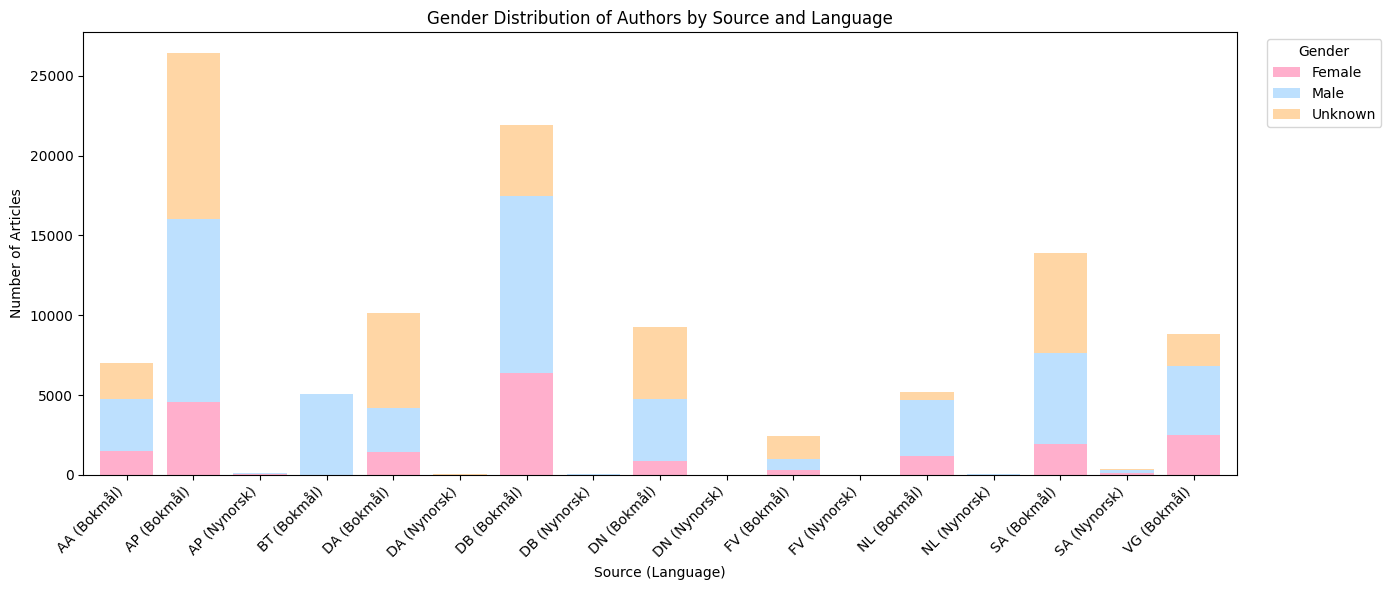

In [ ]:
gender_summary = (
    combined_df.groupby(["source", "language", "gender"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["source", "language", "gender"])
)

plot_df = gender_summary.copy()
plot_df["source_lang"] = plot_df["source"].astype(str) + " (" + plot_df["language"].astype(str) + ")"

pivot_df = (
    plot_df.pivot(index="source_lang", columns="gender", values="count")
    .fillna(0)
    .sort_index()
)

color_map = {
    "Female": "#FFAFCC", 
    "Male": "#BDE0FE",   
    "Unknown": "#FFD6A5",
}
bar_colors = [color_map.get(col, "#CDB4DB") for col in pivot_df.columns]

ax = pivot_df.plot(kind="bar", stacked=True, figsize=(14, 6), width=0.8, color=bar_colors)
ax.set_title("Gender Distribution of Authors by Source and Language")
ax.set_xlabel("Source (Language)")
ax.set_ylabel("Number of Articles")
ax.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### *Check for empty class1 and class2*

In [33]:
# check how many rows have empty class1 for each source and language and print only the ones that are not 0
print("\nChecking for empty class1 field in combined dataset:")
class1_summary = (
    combined_df.assign(empty_class1=combined_df["class1"].str.strip() == "")
    .groupby(["source", "language"], dropna=False)
    .agg(total=("class1", "size"), empty_class1=("empty_class1", "sum"))
    .reset_index()
    .sort_values(["source", "language"])
)
for _, row in class1_summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    empty = int(row["empty_class1"])
    total = int(row["total"])
    pct = (empty / total * 100) if total else 0
    if empty > 0:
        print(f"{src} ({lang}): Articles with empty class1: {empty} / {total} ({pct:.1f}%)")


print("\nChecking for empty class2 field in combined dataset:")
class2_summary = (
    combined_df.assign(empty_class2=combined_df["class2"].str.strip() == "")
    .groupby(["source", "language"], dropna=False)
    .agg(total=("class2", "size"), empty_class2=("empty_class2", "sum"))
    .reset_index()
    .sort_values(["source", "language"])
)
for _, row in class2_summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    empty = int(row["empty_class2"])
    total = int(row["total"])
    pct = (empty / total * 100) if total else 0
    if empty > 0:
        print(f"{src} ({lang}): Articles with empty class2: {empty} / {total} ({pct:.1f}%)")


Checking for empty class1 field in combined dataset:
DN (Bokmål): Articles with empty class1: 289 / 9261 (3.1%)
NL (Bokmål): Articles with empty class1: 5190 / 5196 (99.9%)
NL (Nynorsk): Articles with empty class1: 63 / 63 (100.0%)

Checking for empty class2 field in combined dataset:
AA (Bokmål): Articles with empty class2: 7039 / 7039 (100.0%)
AP (Bokmål): Articles with empty class2: 9022 / 26399 (34.2%)
AP (Nynorsk): Articles with empty class2: 21 / 94 (22.3%)
BT (Bokmål): Articles with empty class2: 2342 / 5091 (46.0%)
DA (Bokmål): Articles with empty class2: 10169 / 10169 (100.0%)
DA (Nynorsk): Articles with empty class2: 32 / 32 (100.0%)
DB (Bokmål): Articles with empty class2: 10951 / 21921 (50.0%)
DB (Nynorsk): Articles with empty class2: 19 / 63 (30.2%)
NL (Bokmål): Articles with empty class2: 5196 / 5196 (100.0%)
NL (Nynorsk): Articles with empty class2: 63 / 63 (100.0%)
SA (Bokmål): Articles with empty class2: 5429 / 13918 (39.0%)
SA (Nynorsk): Articles with empty class2: 1

In [34]:
# Fill "" in class1 and class2 with "None"
combined_df["class1"] = combined_df["class1"].str.strip().replace("", "None")
combined_df["class2"] = combined_df["class2"].str.strip().replace("", "None")

### *Save preprocessed combined dataset*

In [35]:
combined_df.head(5)

,file,url,source,date,author,gender,class1,class2,language,title,ingress,text,word_count,sentence_count
0,VG-20190101-16-personer-fikk-oye.xml,http://www.vg.no/nyheter/innenriks/i/jPyoyb/16...,VG,2019-01-01 09:12,Halvor Bjørntvedt,Male,"nyheter,innenriks",None,Bokmål,16 personer fikk øyeskader av fyrverkeri,Fem fikk alvorlige skader etter gårsdagens nyt...,"Tallene, som viser øyeskader på landsbasis, vi...",209,13
1,VG-20190101-47-plass-for-sundby-.xml,http://www.vg.no/sport/langrenn/i/3j8ra0/47-pl...,VG,2019-01-01 10:19,"Nils Mangelrød, Jostein Overvik",Male,"sport,langrenn",None,Bokmål,47. plass for Sundby - nekter å prate etter ne...,VAL MÜSTAIR (VG) Martin Johnsrud nektet å prat...,Den tidligere Tour de Ski-vinneren var svært l...,533,42
2,VG-20190101-94-drap-pa-journalis.xml,http://www.vg.no/nyheter/utenriks/i/J19kWP/94-...,VG,2019-01-01 21:37,Mikal Hem,Male,"nyheter,utenriks","Drap, Ytringsfrihet, Journalistikk, Korrupsjon...",Bokmål,94 drap på journalister i 2018: Skal ha blitt ...,Antall drepte journalister i Vesten har skutt ...,25. februar ble Jan Kuciak og hans forlovede M...,539,44
3,VG-20190101-alpin-fiasko-i-kolle.xml,http://www.vg.no/sport/alpint/i/VR7Kb6/alpin-f...,VG,2019-01-01 16:09,Herman Tinius Folvik,Male,"sport,alpint",None,Bokmål,Alpin-fiasko i Kollen: Alle de norske slått ut...,"De store håpene, Henrik Kristoffersen og Ragnh...",Mowinckel kunne trolig ikke fått en tøffere mo...,190,21
4,VG-20190101-arsenal-slo-tilbake-.xml,http://www.vg.no/sport/fotball/i/EoPO3l/arsena...,VG,2019-01-01 16:54,Yngve Gjerde,Male,"sport,fotball",None,Bokmål,Arsenal slo tilbake etter Liverpool-fadesen,(Arsenal – Fulham 4 – 1) Arsenal avsluttet fot...,"Scoringer fra Granit Xhaka, Alexandre Lacazett...",272,15


### *Print number of articles after preprocessing*

In [ ]:
print("\nTotal articles in combined dataset after preprocessing:")
print("-" * 50)
final_summary = (
    combined_df.groupby(["source", "language"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["source", "language"])
)
for _, row in final_summary.iterrows():
    src = str(row["source"])
    lang = str(row["language"])
    count = int(row["count"])
    print(f"{src} ({lang}): Number of articles: {count}")


Total articles in combined dataset after preprocessing:
--------------------------------------------------
AA (Bokmål): Number of articles: 7039
AP (Bokmål): Number of articles: 26399
AP (Nynorsk): Number of articles: 94
BT (Bokmål): Number of articles: 5091
DA (Bokmål): Number of articles: 10169
DA (Nynorsk): Number of articles: 32
DB (Bokmål): Number of articles: 21921
DB (Nynorsk): Number of articles: 63
DN (Bokmål): Number of articles: 9261
DN (Nynorsk): Number of articles: 16
FV (Bokmål): Number of articles: 2456
FV (Nynorsk): Number of articles: 4
NL (Bokmål): Number of articles: 5196
NL (Nynorsk): Number of articles: 63
SA (Bokmål): Number of articles: 13918
SA (Nynorsk): Number of articles: 347
VG (Bokmål): Number of articles: 8823


In [37]:
# save the combined dataframe
combined_df.to_parquet("../analysis/combined-2019.parquet", index=False)